# Perceived irrelevance: analysis

This notebook contains all the analysis and data preparation steps for generating the results and figures of the analysis.

## BIDS conversion
Converting the data from the format specific to our implementation in labVanced to a bids-like format for convenience of processing. In our experiment, part of the data were collected in the lab, while the rest was collected online. This information is added to the participants.tsv for later reference

In [3]:
# Convert the data to BIDS
from config import source_root, bids_root, colors
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest, fisher_exact
from statsmodels.stats.contingency_tables import mcnemar
import os

from bids_conversion import beh_cleanup, get_demo, get_subjects_list, dataframe2bids, exclusion_criterion, count_trailing_zeros_after_decimal

# Specify the name of the task:
task = 'PerceivedIrrelevance'

# Prepare participants.tsv:
participants = pd.DataFrame(columns=['participant_id', 'sex', 'age', 'online'])

# List all lab participants
source_root = r'P:\2023-0383-PerceiveIrrelevance\03data\perceivedIrrelevance'
lab_root = Path(source_root, 'labExperiment', 'rawDataLab')
lab_participants = get_subjects_list(lab_root)

for participant in lab_participants:
    # Load the data and clean up the data to a format that is compatible to the BIDS standards:
    events_log = beh_cleanup(lab_root, participant)
    # Apply exclusion criterion:
    excluded = exclusion_criterion(events_log)
    # Save it to a tsv file:
    dataframe2bids(events_log, bids_root, participant, task, data_type='beh', json_sidecar=None)
    # Get the demographic info for that subject:
    age, gender = get_demo(lab_root, participant)
    # Add the participant info:
    participants = pd.concat([participants, pd.DataFrame({
        'participant_id': participant,
        'sex': gender,
        'age': age,
        'online': False,
        'excluded': excluded
    }, index=[0])], ignore_index=True)

# List all online participants
online_root = Path(source_root, 'onlineExperiment', 'rawData')
online_participants = get_subjects_list(online_root)

for participant in online_participants:
    # Load the data and clean up the data to a format that is compatible to the BIDS standards:
    events_log = beh_cleanup(online_root, participant)
    # Apply exclusion criterion:
    excluded = exclusion_criterion(events_log)
    # Save it to a tsv file:
    dataframe2bids(events_log, bids_root, participant, 'PerceivedIrrelevance', data_type='beh', json_sidecar=None)
    # Get the demographic info for that subject:
    age, gender = get_demo(online_root, participant)
    # Add the participant info:
    participants = pd.concat([participants, pd.DataFrame({
        'participant_id': participant,
        'sex': gender,
        'age': age,
        'online': True,
        'excluded': excluded
    }, index=[0])], ignore_index=True)

# Save the participants table:
file_name_demo = "participants.tsv"
file_path_demo = Path(bids_root, file_name_demo)
if os.path.isfile(file_path_demo):
    participants_tsv = pd.read_csv(file_path_demo, sep='\t')
    participants = pd.concat([participants_tsv, participants])
# Save the DataFrame to TSV format
participants.to_csv(file_path_demo, sep='\t', index=False)


## Demographics
Computing descriptive statistics of our participants:

In [2]:
# Load the demographic data:
participants_demo = pd.read_csv(file_path_demo, sep='\t')
participants_demo.head()

,participant_id,sex,age,online,excluded
0,Sub101,female,24.0,False,False
1,Sub102,female,28.0,False,False
2,Sub103,male,27.0,False,False
3,Sub104,female,25.0,False,False
4,Sub105,male,25.0,False,False


In [3]:
# Compute participants mean age and standard deviation:
n_females = participants_demo[participants_demo['sex'] == 'female'].shape[0]
mean_age = round(participants_demo['age'].mean(), 2)
std_dev_age = round(participants_demo['age'].std(), 2)
print(f'N Females={n_females}, aged {mean_age} ± {std_dev_age}')

N Females=30, aged 27.24 ± 4.32


In [4]:
# Compute age of in lab participants:
n_females = participants_demo[(participants_demo['online'] == False) & (participants_demo['sex'] == 'female')].shape[0]
mean_age = round(participants_demo[participants_demo['online'] == False]['age'].mean(), 2)
std_dev_age = round(participants_demo[participants_demo['online'] == False]['age'].std(), 2)
print(f'N Females={n_females}, aged {mean_age} ± {std_dev_age}')

N Females=10, aged 26.43 ± 2.54


In [5]:
# Compute age of online participants:
n_females = participants_demo[(participants_demo['online'] == True) & (participants_demo['sex'] == 'female')].shape[0]
mean_age = round(participants_demo[participants_demo['online'] == True]['age'].mean(), 2)
std_dev_age = round(participants_demo[participants_demo['online'] == True]['age'].std(), 2)
print(f'N Females={n_females}, aged {mean_age} ± {std_dev_age}')

N Females=20, aged 27.62 ± 4.93


## Analysis
Loading the data of each participants, excluding those that did not pass the exclusion criterion:

In [6]:
# Load the data of all subjects:
subjects_df = []
for sub in participants_demo['participant_id'].to_list():
    if participants_demo.loc[participants_demo['participant_id'] == sub, 'excluded'].values[0]:
        print(f'Subject {sub} excluded')
        continue
    # Load the events.tsv:
    file_path = Path(bids_root, sub, 'beh', f'{sub}_task-{task}_events.tsv')
    subject_df = pd.read_csv(file_path, sep='\t')
    # Add wheter the subject was collected in the lab or not for later reference:
    subject_df['online'] = participants_demo.loc[participants_demo['participant_id'] == sub, 'online'].values[0]
    # Add subject id for later reference:
    subject_df['participant_id'] = sub
    subjects_df.append(subject_df)
subjects_df = pd.concat(subjects_df, ignore_index=True)

In [23]:
# Count the participants for each conditions of interest
subjects_df.groupby(['target_group', 'probe_order', 'congruency'])['participant_id'].nunique().reset_index(name='participant_count')

,target_group,probe_order,congruency,participant_count
0,Face,durationFirst,congruent,9
1,Face,durationFirst,incongruent,9
2,Face,orientationFirst,congruent,9
3,Face,orientationFirst,incongruent,9
4,Object,durationFirst,congruent,9
5,Object,durationFirst,incongruent,9
6,Object,orientationFirst,congruent,9
7,Object,orientationFirst,incongruent,9


### Surprise trial analysis:

The main research question of this experiment is whether participants can remember task irrelevant features: orientation and duration. Importantly, we have two groups of participants: half were presented a face as surprise trials, others were presented an object. It is likely that memory performance differ between these two types of stimuli. Accordingly, we will assess the memory performance separately for the faces and objects by comparing the memory performances against chance using a binomial test. To test whether a difference between face and objects exist, we will compare the memory performance between both conditions separately of the duration and memory probe using a Fisher exact's test. In addition, a subset of participants was collected in the lab, while the rest was collected online. We will first analyse them separately before combining them.

In [ ]:
# Extract the results of the surprise probe for orientation and duration separately:
surprise_probe_data = subjects_df[(subjects_df['block_type'] == 'surprise') & 
                                  ((subjects_df['event_type'] == 'probe_duration') | 
                                   (subjects_df['event_type'] == 'probe_orientation'))].reset_index(drop=True)

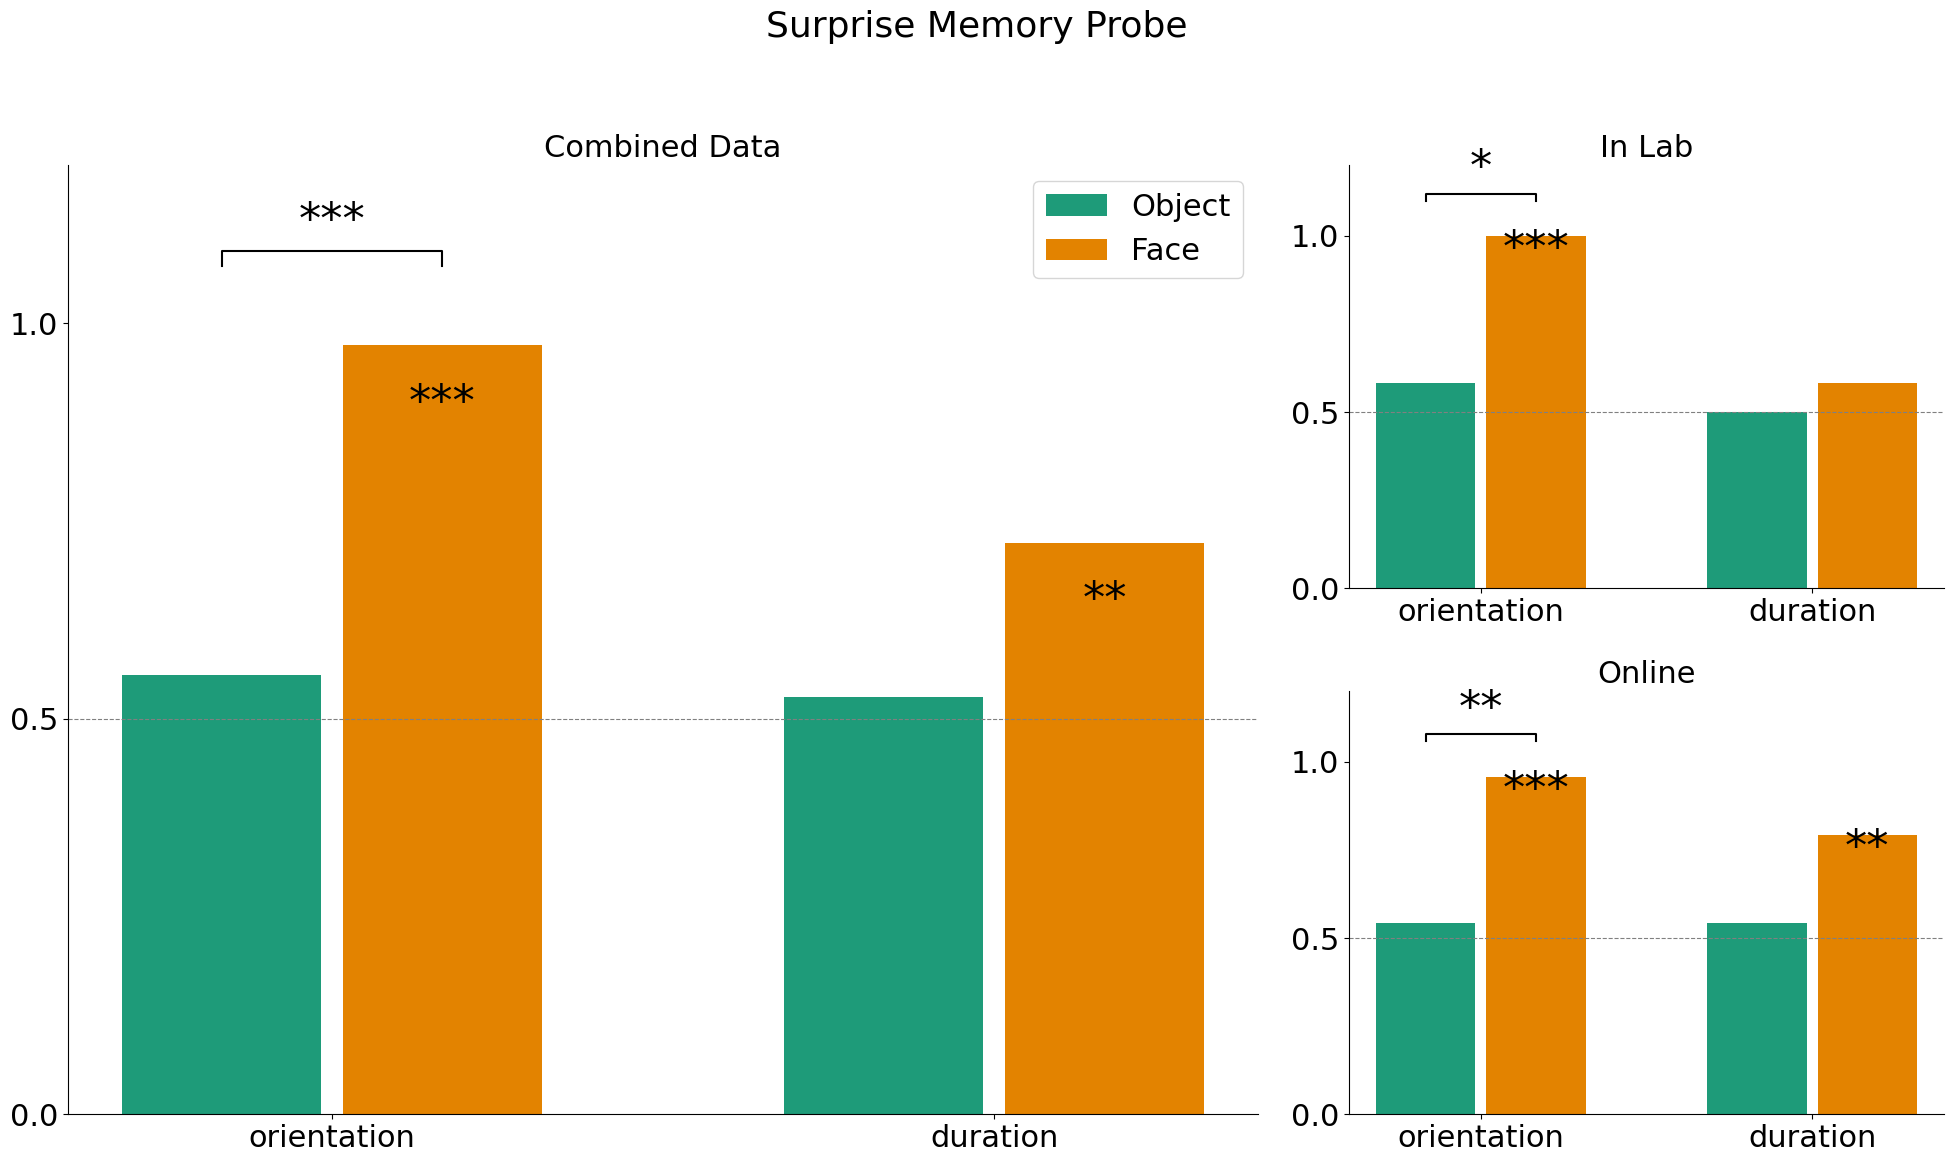

In [9]:
#| label: Figure2


fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Axes for combined and separate plots
ax_combined = fig.add_subplot(gs[:, 0])  # Combined plot takes the left 2x1 space
ax_lab = fig.add_subplot(gs[0, 1])       # Top-right for in-lab data
ax_online = fig.add_subplot(gs[1, 1])    # Bottom-right for online data

# Data and settings
online_flags = [False, True]
probe_types = ['orientation', 'duration']
target_groups = ['Object', 'Face']
bar_width = 0.9

results_binomial = pd.DataFrame(columns=['Participants', '# Subjects', 'probe', 'category', 'Memory', 'p-value'])
results_fisher = pd.DataFrame(columns=['Participants', '# Subjects', 'probe', 'Objects', 'Faces', 'statistic', 'p-value'])

# Plot combined data (left side)
ctr = 0
for ii, prb in enumerate(probe_types):
    tbl = np.zeros((2, 2))
    ctr += 1
    for iii, grp in enumerate(target_groups):
        df = surprise_probe_data[(surprise_probe_data['event_type'] == f'probe_{prb}') &
                                 (surprise_probe_data['target_group'] == grp)]
        if prb == 'duration':
            data = df['duration_str'].to_numpy() == df['response'].to_numpy()
        else:
            data = df['orientation'].to_numpy() == df['response'].to_numpy()

        tbl[0, iii] = np.sum(data)
        tbl[1, iii] = data.shape[0] - np.sum(data)
        
        res = binomtest(np.sum(data), data.shape[0], alternative='greater')
        bar_height = np.sum(data) / data.shape[0]
        ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, label=grp if ii == 0 else "")
        
        if res.pvalue < 0.05:
            sig_lvl = '*' * min(3, -int(np.log10(res.pvalue)))
            ax_combined.text(ctr, bar_height - 0.1, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
        # Add the results to the table:
        results_binomial = pd.concat([results_binomial, pd.DataFrame({
            'Participants': 'combined',
            '# Subjects': data.shape[0],
            'probe': prb,
            'category': grp,
            'Memory': np.round(bar_height, 2),
            'p-value': np.round(res.pvalue, 3)
        }, index=[0])], ignore_index=True)
        ctr += 1

    res = fisher_exact(tbl)

    # Add the results to the table:
    results_fisher = pd.concat([results_fisher, pd.DataFrame({
            'Participants': 'combined',
            '# Subjects': f'{int(np.sum(tbl[:, 0]))}|{int(np.sum(tbl[:, 0]))}',
            'probe': prb,
            'Faces': np.round(tbl[0, 0] / (np.sum(tbl[0, :])), 2),
            'Objects': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),
            'statistic': res.statistic,
            'p-value': np.round(res.pvalue, 3)
        }, index=[0])], ignore_index=True)

    if res.pvalue < 0.05:
        x1, x2 = ctr - 2, ctr - 1
        y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1
        ax_combined.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
        sig_lvl = '*' * min(3, -int(np.log10(res.pvalue)))
        ax_combined.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')

# Customize combined plot
ax_combined.legend()
ax_combined.set_title("Combined Data")
ax_combined.set_xticks([1.5, 4.5])
ax_combined.set_xticklabels(probe_types)
ax_combined.spines[['right', 'top']].set_visible(False)
ax_combined.set_ylim(0, 1.2)
ax_combined.set_yticks([0, 0.5, 1])
ax_combined.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Plot separately in-lab and online (right side)
for i, (ax, online) in enumerate(zip([ax_lab, ax_online], online_flags)):
    ctr = 0
    for ii, prb in enumerate(probe_types):
        tbl = np.zeros((2, 2))
        ctr += 1
        for iii, grp in enumerate(target_groups):
            df = surprise_probe_data[(surprise_probe_data['online'] == online) &
                                     (surprise_probe_data['event_type'] == f'probe_{prb}') &
                                     (surprise_probe_data['target_group'] == grp)]
            if prb == 'duration':
                data = df['duration_str'].to_numpy() == df['response'].to_numpy()
            else:
                data = df['orientation'].to_numpy() == df['response'].to_numpy()
            
            tbl[0, iii] = np.sum(data)
            tbl[1, iii] = data.shape[0] - np.sum(data)
            
            res = binomtest(np.sum(data), data.shape[0], alternative='greater')
            bar_height = np.sum(data) / data.shape[0]
            ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width)
            
            if res.pvalue < 0.05:
                sig_lvl = '*' * min(3, -int(np.log10(res.pvalue)))
                ax.text(ctr, bar_height - 0.1, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
            
            results_binomial = pd.concat([results_binomial, pd.DataFrame({
                'Participants': 'online' if online else 'In lab',
                '# Subjects': data.shape[0],
                'probe': prb,
                'category': grp,
                'Memory': np.round(bar_height, 2),
                'p-value': np.round(res.pvalue, 3)
            }, index=[0])], ignore_index=True)

            ctr += 1
        
        res = fisher_exact(tbl)

        # Add the results to the table:
        results_fisher = pd.concat([results_fisher, pd.DataFrame({
                'Participants': 'online' if online else 'In lab',
                '# Subjects': f'{int(np.sum(tbl[:, 0]))}|{int(np.sum(tbl[:, 0]))}',
                'probe': prb,
                'Faces': np.round(tbl[0, 0] / (np.sum(tbl[0, :])), 2),
                'Objects': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),
                'statistic': np.round(res.statistic, 2),
                'p-value': np.round(res.pvalue, 3)
            }, index=[0])], ignore_index=True)

        if res.pvalue < 0.05:
            x1, x2 = ctr - 2, ctr - 1
            y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1
            ax.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
            sig_lvl = '*' * min(3, -int(np.log10(res.pvalue)))
            ax.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
    
    ax.set_title('Online' if online else 'In Lab')
    ax.set_xticks([1.5, 4.5])
    ax.set_xticklabels(probe_types)
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0, 0.5, 1])
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Surprise Memory Probe')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [10]:
#| label: Table1
results_binomial

,Participants,# Subjects,probe,category,Memory,p-value
0,combined,36,orientation,Object,0.56,0.309
1,combined,36,orientation,Face,0.97,0.000
2,combined,36,duration,Object,0.53,0.434
3,combined,36,duration,Face,0.72,0.006
4,In lab,12,orientation,Object,0.58,0.387
5,In lab,12,orientation,Face,1.00,0.000
6,In lab,12,duration,Object,0.50,0.613
7,In lab,12,duration,Face,0.58,0.387
8,online,24,orientation,Object,0.54,0.419
9,online,24,orientation,Face,0.96,0.000


In [11]:
#| label: Table2
results_fisher

,Participants,# Subjects,probe,Objects,Faces,statistic,p-value
0,combined,36|36,orientation,0.94,0.36,0.035714,0.000
1,combined,36|36,duration,0.63,0.42,0.429864,0.144
2,In lab,12|12,orientation,1.00,0.37,0.000000,0.037
3,In lab,12|12,duration,0.55,0.46,0.710000,1.000
4,online,24|24,orientation,0.92,0.36,0.050000,0.002
5,online,24|24,duration,0.69,0.41,0.310000,0.125


In the combined data set, we observe that participants are able to remember both orientation and duration, but only when the presented stimulus was a face. Participants are significantly better at remembering face orientation than object orientation. The difference between faces and objects is not significant for duration, which may be due to the effect size being smaller, as memory performances for faces duration is also lower. Similar trends are observed in both in lab and online participants, though not always significant, due to the smaller sample size.

### Order effect:
In our task, in order to avoid order effects, we counter-balanced which of the two features is asked first across participants. However, it is likely that task irrelevant features decay from memory rather fast, in which case the likelihood of a feature being remembered depends on whether the probe appeared first or second. To investigate this possibility, we compared the memory performance of each feature for each stimulus category separately depending on whether the probe occured first or not:

C:\Users\alexander.lepauvre\AppData\Local\Temp\ipykernel_31952\906189784.py:57: RuntimeWarning: invalid value encountered in scalar divide
  'second': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),


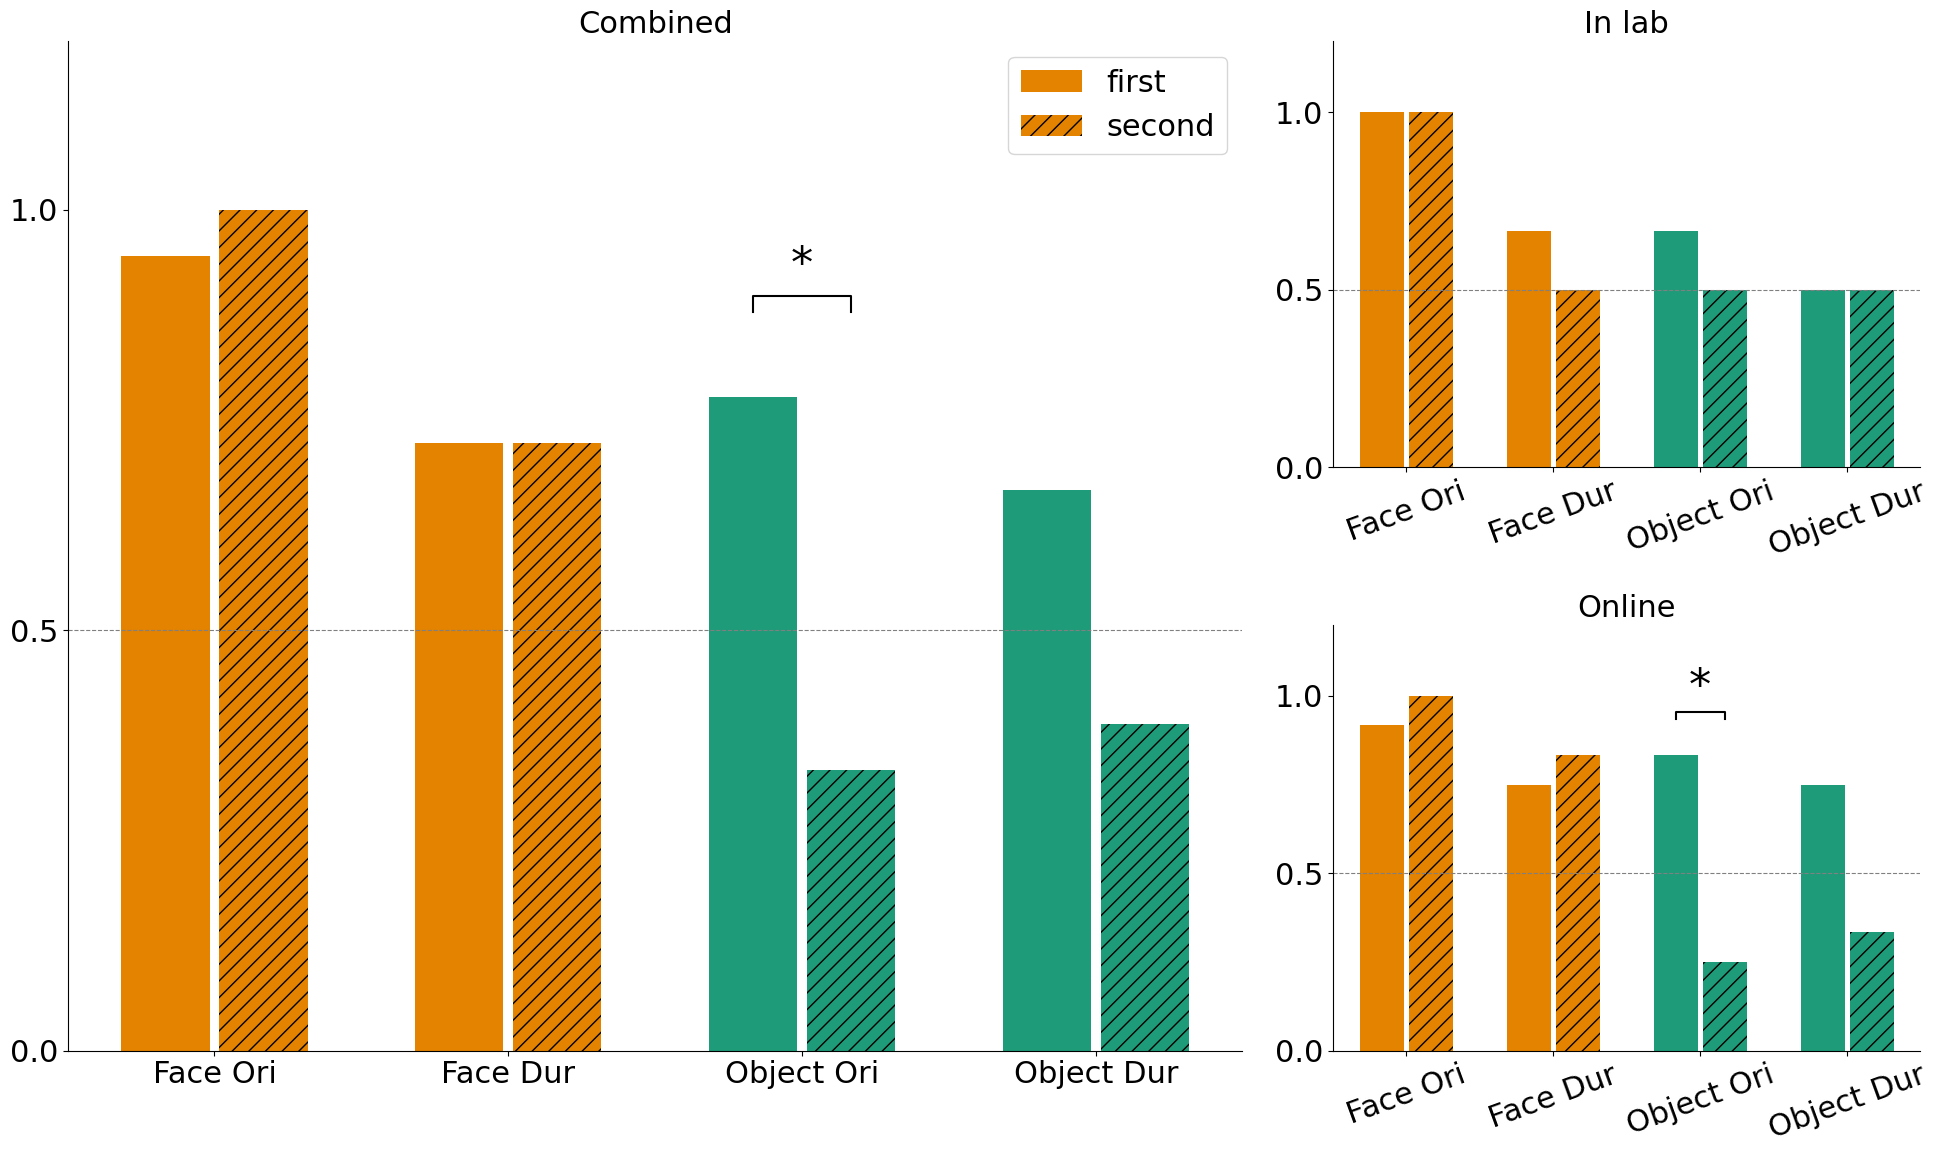

In [12]:
#| label: Figure3

# Investigate the order effect:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Axes for combined and separate plots
ax_combined = fig.add_subplot(gs[:, 0])  # Combined plot takes the left 2x1 space
ax_lab = fig.add_subplot(gs[0, 1])       # Top-right for in-lab data
ax_online = fig.add_subplot(gs[1, 1])    # Bottom-right for online data

results_fisher = pd.DataFrame(columns=['Participants', '# Subjects', 'probe', 'category', 'first', 'second', 'statistic', 'p-value'])

# In lab study face orientation:
for i, (ax, online) in enumerate(zip([ax_lab, ax_online], online_flags)):
    ctr = 0
    for ii, grp in enumerate(['Face', 'Object']):
        for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
            ctr += 1
            tbl = np.zeros((2, 2))
            if prb == 'probe_orientation':
                order = ['orientationFirst', 'durationFirst']
            else:
                order = ['durationFirst', 'orientationFirst']
            lgd = ['first', 'second']
            for iiii, ord in enumerate(order):
                df = surprise_probe_data[(surprise_probe_data['online'] == online) &
                                            (surprise_probe_data['event_type'] == prb) &
                                            (surprise_probe_data['target_group'] == grp) & 
                                            (surprise_probe_data['probe_order'] == ord)]
                # Extract probed first:
                if prb == 'probe_orientation':
                    data = df['orientation'].to_numpy() == df['response'].to_numpy()
                else:
                    data = df['duration_str'].to_numpy() == df['response'].to_numpy()
                # Populate the contingency table to compare the two groups:
                tbl[0, iiii] = np.sum(data)
                tbl[1, iiii] = data.shape[0] - np.sum(data) 
                # Plot the results:
                bar_height = np.sum(data) / data.shape[0]
                if iiii == 0:
                    ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width)
                else:
                    ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, hatch='//')
                ctr += 1
            
            # Fisher exact test between both conditions:
            res = fisher_exact(tbl)

            # Add the results to the table:
            results_fisher = pd.concat([results_fisher, pd.DataFrame({
                    'Participants': 'online' if online else 'In lab',
                    '# Subjects': f'{int(np.sum(tbl[:, 0]))}|{int(np.sum(tbl[:, 0]))}',
                    'probe': prb,
                    'category': grp,
                    'first': np.round(tbl[0, 0] / (np.sum(tbl[0, :])), 2),
                    'second': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),
                    'statistic': np.round(res.statistic, 2),
                    'p-value': np.round(res.pvalue, 3)
                }, index=[0])], ignore_index=True)
            
            if res.pvalue < 0.05:
                x1 = ctr - 2  # Position of the first bar (Object)
                x2 = ctr - 1  # Position of the second bar (Face)
                y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1  # Height for the significance line
                ax.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
                # Set the asterisk:
                sig_lvl = '***' if count_trailing_zeros_after_decimal(res.pvalue) > 3 else '*' * count_trailing_zeros_after_decimal(res.pvalue)
                ax.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
            
        # Customize each subplot
    if online:
        ax.set_title(f'Online')
    else:
        ax.set_title(f'In lab')
    ax.set_xticks([1.5, 4.5, 7.5, 10.5])
    ax.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'], rotation=20)
    ax.spines[['right', 'top']].set_visible(False)
    # Set y-axis limits and ticks, with a dashed line at 0.5
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0, 0.5, 1])
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Combined
i = 2
ctr = 0
for ii, grp in enumerate(['Face', 'Object']):
    for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
        ctr += 1
        tbl = np.zeros((2, 2))
        if prb == 'probe_orientation':
            order = ['orientationFirst', 'durationFirst']
        else:
            order = ['durationFirst', 'orientationFirst']
        lgd = ['first', 'second']
        for iiii, ord in enumerate(order):
            df = surprise_probe_data[(surprise_probe_data['event_type'] == prb) &
                                        (surprise_probe_data['target_group'] == grp) & 
                                        (surprise_probe_data['probe_order'] == ord)]
            # Extract probed first:
            if prb == 'probe_orientation':
                data = df['orientation'].to_numpy() == df['response'].to_numpy()
            else:
                data = df['duration_str'].to_numpy() == df['response'].to_numpy()
            # Populate the contingency table to compare the two groups:
            tbl[0, iiii] = np.sum(data)
            tbl[1, iiii] = data.shape[0] - np.sum(data) 
            # Plot the results:
            bar_height = np.sum(data) / data.shape[0]
            if iiii == 0:
                ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, label=lgd[iiii] if ctr == 1 else "")
            else:
                ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, hatch='//', label=lgd[iiii] if ctr == 2 else "")
            ctr += 1
        
        # Fisher exact test between both conditions:
        res = fisher_exact(tbl)

        # Add the results to the table:
        results_fisher = pd.concat([results_fisher, pd.DataFrame({
                'Participants': 'combined',
                '# Subjects': f'{int(np.sum(tbl[:, 0]))}|{int(np.sum(tbl[:, 0]))}',
                'probe': prb,
                'category': grp,
                'first': np.round(tbl[0, 0] / (np.sum(tbl[0, :])), 2),
                'second': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),
                'statistic': np.round(res.statistic, 2),
                'p-value': np.round(res.pvalue, 3)
            }, index=[0])], ignore_index=True)

        if res.pvalue < 0.05:
            x1 = ctr - 2  # Position of the first bar (Object)
            x2 = ctr - 1  # Position of the second bar (Face)
            y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1  # Height for the significance line
            ax_combined.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
            # Set the asterisk:
            sig_lvl = '***' if count_trailing_zeros_after_decimal(res.pvalue) > 3 else '*' * count_trailing_zeros_after_decimal(res.pvalue)
            ax_combined.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
        
ax_combined.set_xticks([1.5, 4.5, 7.5, 10.5])
ax_combined.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'])
ax_combined.spines[['right', 'top']].set_visible(False)
# Set y-axis limits and ticks, with a dashed line at 0.5
ax_combined.set_ylim(0, 1.2)
ax_combined.set_yticks([0, 0.5, 1])
ax_combined.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax_combined.legend()
ax_combined.set_title("Combined")
plt.tight_layout()
plt.show()
plt.close()

In [13]:
#| label: Table3
results_fisher

,Participants,# Subjects,probe,category,first,second,statistic,p-value
0,In lab,6|6,probe_orientation,Face,0.50,NaN,NaN,1.000
1,In lab,6|6,probe_duration,Face,0.57,0.40,2.00,1.000
2,In lab,6|6,probe_orientation,Object,0.57,0.40,2.00,1.000
3,In lab,6|6,probe_duration,Object,0.50,0.50,1.00,1.000
4,online,12|12,probe_orientation,Face,0.48,1.00,0.00,1.000
5,online,12|12,probe_duration,Face,0.47,0.60,0.60,1.000
6,online,12|12,probe_orientation,Object,0.77,0.18,15.00,0.012
7,online,12|12,probe_duration,Object,0.69,0.27,6.00,0.100
8,combined,18|18,probe_orientation,Face,0.49,1.00,0.00,1.000
9,combined,18|18,probe_duration,Face,0.50,0.50,1.00,1.000


There seems to be a trend, such that the features asked second are remembered slightly worst, but it is not a very clear effect and the fisher exact test is not significant. It is not too surprising, as we have very few observation in each group. If anything, the effect seems to be most consistent for objects

### Memory performance change in the first post-surprise trial
Participants did not remember orientation or duration perfectly for task-irrelevant features, except for faces. To assess whether poor memory in surprise trials was due to the difficulty of memorizing those features or simply their irrelevance, we compare memory performance in surprise vs. post-surprise trials, where these features became relevant.

In post-surprise trials, we counterbalanced stimulus categories so that half the participants saw a stimulus of the same category as in the surprise trial first, and the other half saw a different category. Accordingly, only half the participants saw a stimulus of the same category in the surprise and post-surprise category. As we are most insterested in the memory performance separately for faces and objects, we need to compare the memory performance between the surprise and post-surprise trials of the same category. Based on our design, this can be achieved in two ways:

1. Compare face surprise trials with all face first post-surprise trials (and similary for objects). In this case, half of the subjects that were shown a face in the post-surprise trial were not shown a a face in the surprise trial. To perform this comparison, we use a Fisher exact test, because for half of the subjects, the comparison is between subjects. 
2. Select participants with congruent first post-surprise trials: Only participants who saw the same category as in the surprise trial are included. To perform this comparison, we use a McNemar test, as the measures are repeated within subject.

Both approaches will be performed to provide a comprehensive analysis.

In [14]:
# Extract first post-surprise trials probe duration and orientation:
first_post_surprise = subjects_df[(subjects_df['block_type'] == 'post-surprise') & 
                                  (subjects_df['event_type'].isin(['probe_duration', 'probe_orientation']))].reset_index().groupby(['participant_id', 'event_type']).first().reset_index()

surprise_vs_post = pd.concat([surprise_probe_data, first_post_surprise], ignore_index=True)

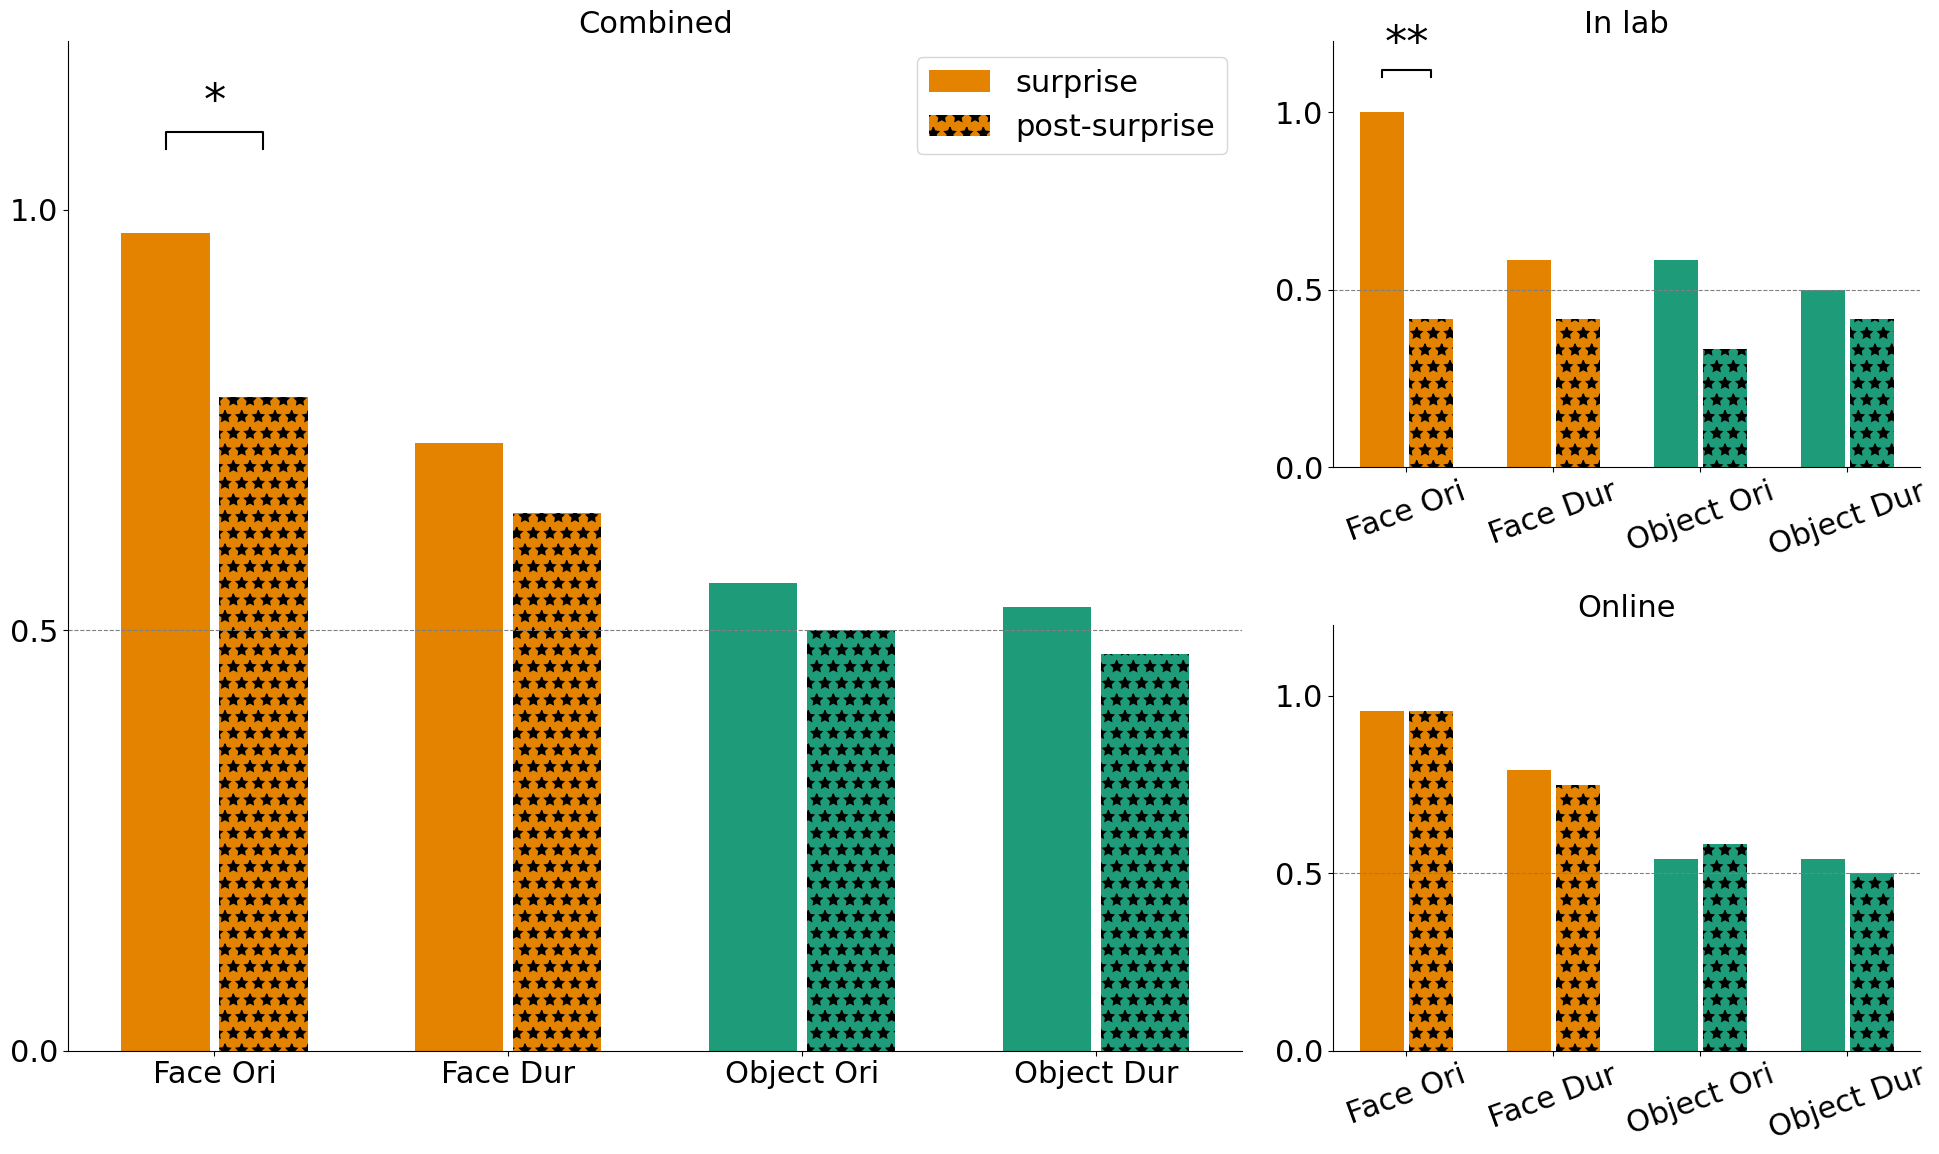

In [15]:
#| label: Figure4

# Plot the surprise vs. post surprise:
# Investigate the order effect:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Axes for combined and separate plots
ax_combined = fig.add_subplot(gs[:, 0])  # Combined plot takes the left 2x1 space
ax_lab = fig.add_subplot(gs[0, 1])       # Top-right for in-lab data
ax_online = fig.add_subplot(gs[1, 1])    # Bottom-right for online data

results_fisher = pd.DataFrame(columns=['Participants', '# Subjects', 'probe', 'category', 'surprise', 'post-surprise', 'statistic', 'p-value'])

# Block types:
block_types = ['surprise', 'post-surprise']

# In lab study face orientation:
for i, (ax, online) in enumerate(zip([ax_lab, ax_online], online_flags)):
    ctr = 0
    for ii, grp in enumerate(['Face', 'Object']):
        for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
            ctr += 1
            tbl = np.zeros((2, 2))
            for iiii, blk in enumerate(block_types):
                if blk == 'surprise':
                    df = surprise_vs_post[(surprise_vs_post['online'] == online) &
                                                (surprise_vs_post['event_type'] == prb) &
                                                (surprise_vs_post['target_group'] == grp) & 
                                                (surprise_vs_post['block_type'] == blk)]
                else:
                    df = surprise_vs_post[(surprise_vs_post['online'] == online) &
                            (surprise_vs_post['event_type'] == prb) &
                            (surprise_vs_post['block_type'] == blk) &
                            (surprise_vs_post['category'] == grp.lower())]
                # Extract probed first:
                if prb == 'probe_orientation':
                    data = df['orientation'].to_numpy() == df['response'].to_numpy()
                else:
                    data = df['duration_str'].to_numpy() == df['response'].to_numpy()
                # Populate the contingency table to compare the two groups:
                tbl[0, iiii] = np.sum(data)
                tbl[1, iiii] = data.shape[0] - np.sum(data) 
                # Plot the results:
                bar_height = np.sum(data) / data.shape[0]
                if iiii == 0:
                    ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width)
                else:
                    ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, hatch='*')
                ctr += 1
            # Fisher exact test between both conditions:
            res = fisher_exact(tbl)

            # Add the results to the table:
            results_fisher = pd.concat([results_fisher, pd.DataFrame({
                    'Participants': 'online' if online else 'In lab',
                    '# Subjects': f'{int(np.sum(tbl[:, 0]))}|{int(np.sum(tbl[:, 0]))}',
                    'probe': prb,
                    'category': grp,
                    'surprise': np.round(tbl[0, 0] / (np.sum(tbl[0, :])), 2),
                    'post-surprise': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),
                    'statistic': np.round(res.statistic, 2),
                    'p-value': np.round(res.pvalue, 3)
                }, index=[0])], ignore_index=True)
            
            if res.pvalue < 0.05:
                x1 = ctr - 2  # Position of the first bar (Object)
                x2 = ctr - 1  # Position of the second bar (Face)
                y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1  # Height for the significance line
                ax.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
                # Set the asterisk:
                sig_lvl = '***' if count_trailing_zeros_after_decimal(res.pvalue) > 3 else '*' * count_trailing_zeros_after_decimal(res.pvalue)
                ax.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
            
        # Customize each subplot
    if online:
        ax.set_title(f'Online')
    else:
        ax.set_title(f'In lab')
    ax.set_xticks([1.5, 4.5, 7.5, 10.5])
    ax.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'], rotation=20)
    ax.spines[['right', 'top']].set_visible(False)
    # Set y-axis limits and ticks, with a dashed line at 0.5
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0, 0.5, 1])
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Combined
i = 2
ctr = 0
for ii, grp in enumerate(['Face', 'Object']):
    for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
        ctr += 1
        tbl = np.zeros((2, 2))
        if prb == 'probe_orientation':
            order = ['orientationFirst', 'durationFirst']
        else:
            order = ['durationFirst', 'orientationFirst']
        for iiii, blk in enumerate(block_types):
            if blk == 'surprise':   
                df = surprise_vs_post[(surprise_vs_post['event_type'] == prb) &
                                            (surprise_vs_post['target_group'] == grp) & 
                                            (surprise_vs_post['block_type'] == blk)]
            else:
                df = surprise_vs_post[(surprise_vs_post['event_type'] == prb) &
                            (surprise_vs_post['block_type'] == blk)&
                            (surprise_vs_post['category'] == grp.lower())]
            # Extract probed first:
            if prb == 'probe_orientation':
                data = df['orientation'].to_numpy() == df['response'].to_numpy()
            else:
                data = df['duration_str'].to_numpy() == df['response'].to_numpy()
            # Populate the contingency table to compare the two groups:
            tbl[0, iiii] = np.sum(data)
            tbl[1, iiii] = data.shape[0] - np.sum(data) 
            # Plot the results:
            bar_height = np.sum(data) / data.shape[0]
            if iiii == 0:
                ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, label=block_types[iiii] if ctr == 1 else "")
            else:
                ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, hatch='*', label=block_types[iiii] if ctr == 2 else "")
            ctr += 1
        
        # Fisher exact test between both conditions:
        res = fisher_exact(tbl)

        # Add the results to the table:
        results_fisher = pd.concat([results_fisher, pd.DataFrame({
                'Participants': 'combined',
                '# Subjects': f'{int(np.sum(tbl[:, 0]))}|{int(np.sum(tbl[:, 0]))}',
                'probe': prb,
                'category': grp,
                'surprise': np.round(tbl[0, 0] / (np.sum(tbl[0, :])), 2),
                'post-surprise': np.round(tbl[1, 0] / (np.sum(tbl[1, :])), 2),
                'statistic': np.round(res.statistic, 2),
                'p-value': np.round(res.pvalue, 3)
            }, index=[0])], ignore_index=True)

        if res.pvalue < 0.05:
            x1 = ctr - 2  # Position of the first bar (Object)
            x2 = ctr - 1  # Position of the second bar (Face)
            y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1  # Height for the significance line
            ax_combined.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
            # Set the asterisk:
            sig_lvl = '***' if count_trailing_zeros_after_decimal(res.pvalue) > 3 else '*' * count_trailing_zeros_after_decimal(res.pvalue)
            ax_combined.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
        
ax_combined.set_xticks([1.5, 4.5, 7.5, 10.5])
ax_combined.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'])
ax_combined.spines[['right', 'top']].set_visible(False)
# Set y-axis limits and ticks, with a dashed line at 0.5
ax_combined.set_ylim(0, 1.2)
ax_combined.set_yticks([0, 0.5, 1])
ax_combined.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax_combined.legend()
ax_combined.set_title("Combined")
plt.tight_layout()
plt.show()
plt.close()

In [16]:
#| label: Table4
results_fisher

,Participants,# Subjects,probe,category,surprise,post-surprise,statistic,p-value
0,In lab,12|12,probe_orientation,Face,0.71,0.00,inf,0.005
1,In lab,12|12,probe_duration,Face,0.58,0.42,1.96,0.684
2,In lab,12|12,probe_orientation,Object,0.64,0.38,2.80,0.414
3,In lab,12|12,probe_duration,Object,0.55,0.46,1.40,1.000
4,online,24|24,probe_orientation,Face,0.50,0.50,1.00,1.000
5,online,24|24,probe_duration,Face,0.51,0.45,1.27,1.000
6,online,24|24,probe_orientation,Object,0.48,0.52,0.84,1.000
7,online,24|24,probe_duration,Object,0.52,0.48,1.18,1.000
8,combined,36|36,probe_orientation,Face,0.56,0.11,10.00,0.028
9,combined,36|36,probe_duration,Face,0.53,0.43,1.47,0.614


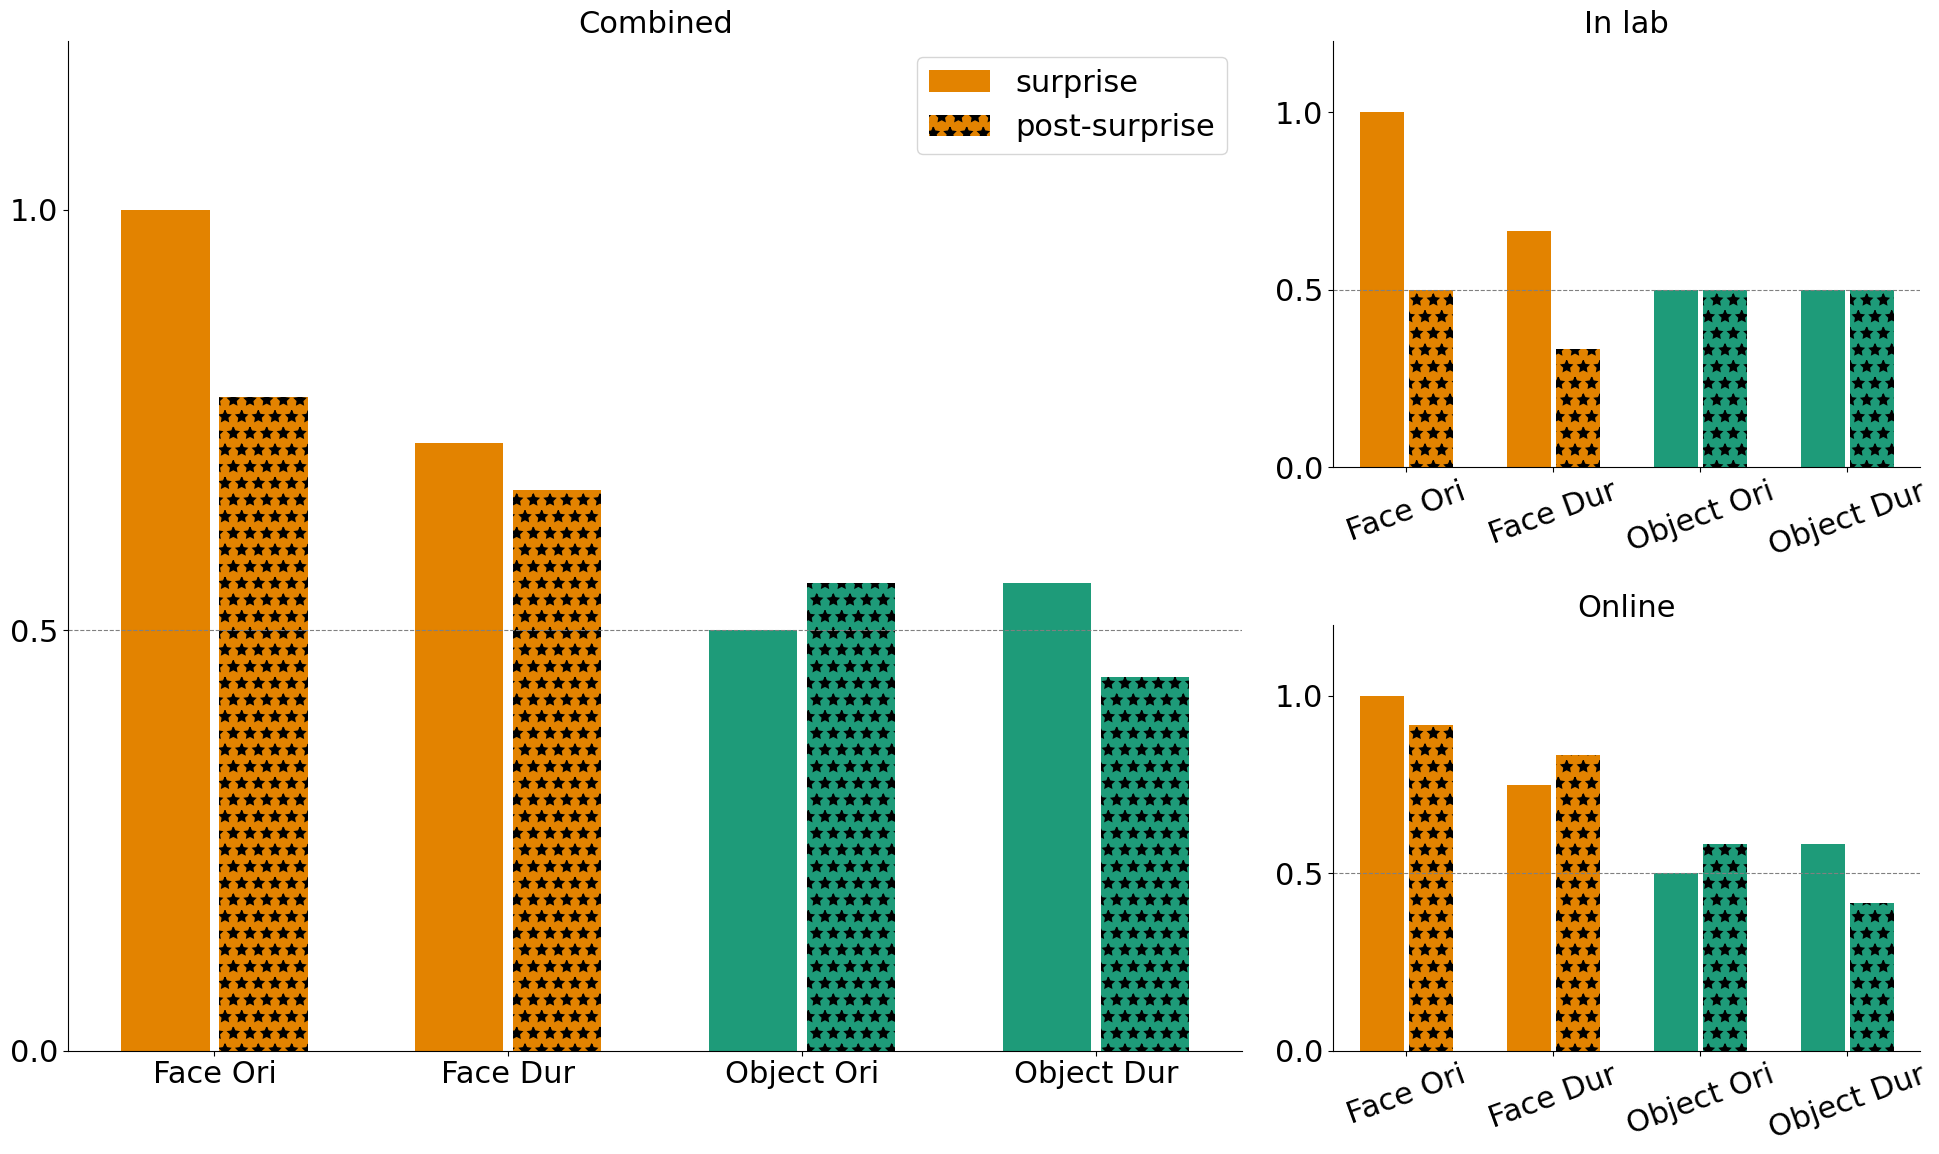

In [22]:
#| label: Figure5
# Investigate only the congruent:
surprise_vs_post_congruent = []
for sub in surprise_vs_post['participant_id'].unique():
    # Extract this subject's data:
    sub_df = surprise_vs_post[surprise_vs_post['participant_id'] == sub]
    # Append that subject only if the first post surprise is of the same category as the target
    if sub_df[sub_df['block_type'] == 'post-surprise']['category'].values[0] == sub_df[sub_df['block_type'] == 'post-surprise']['target_group'].values[0].lower():
        surprise_vs_post_congruent.append(sub_df)
surprise_vs_post_congruent = pd.concat(surprise_vs_post_congruent, ignore_index=True)
# Investigate the order effect:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Axes for combined and separate plots
ax_combined = fig.add_subplot(gs[:, 0])  # Combined plot takes the left 2x1 space
ax_lab = fig.add_subplot(gs[0, 1])       # Top-right for in-lab data
ax_online = fig.add_subplot(gs[1, 1])    # Bottom-right for online data

results_mcnemar = pd.DataFrame(columns=['Participants', '# Subjects', 'probe', 'category', 'surprise', 'post-surprise', 'statistic', 'p-value'])

# Block types:
block_types = ['surprise', 'post-surprise']

# In lab study face orientation:
for i, (ax, online) in enumerate(zip([ax_lab, ax_online], online_flags)):
    ctr = 0
    for ii, grp in enumerate(['Face', 'Object']):
        for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
            ctr += 1
            resp = []  # Store the results of each participants for each trial
            for iiii, blk in enumerate(block_types):
                df = surprise_vs_post_congruent[(surprise_vs_post_congruent['online'] == online) &
                                            (surprise_vs_post_congruent['event_type'] == prb) &
                                            (surprise_vs_post_congruent['target_group'] == grp) & 
                                            (surprise_vs_post_congruent['block_type'] == blk)]
                # Extract probed first:
                if prb == 'probe_orientation':
                    data = df['orientation'].to_numpy() == df['response'].to_numpy()
                else:
                    data = df['duration_str'].to_numpy() == df['response'].to_numpy()
                # Populate the contingency table to compare the two groups:
                resp.append(data)
                # Plot the results:
                bar_height = np.sum(data) / data.shape[0]
                if iiii == 0:
                    ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width)
                else:
                    ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, hatch='*')
                ctr += 1
            # Create the mcnemar table:
            corr_corr = np.sum(resp[0] & resp[1])
            incorr_corr = np.sum(np.logical_not(resp[0]) & resp[1])
            corr_incorr = np.sum(resp[0] & np.logical_not(resp[1]))
            incorr_incorr = np.sum(np.logical_not(resp[0]) & np.logical_not(resp[1]))
            tbl_mcnemar = np.array([[corr_corr, corr_incorr], [incorr_corr, incorr_incorr]])
            # McNemar test between both conditions:
            res = mcnemar(tbl_mcnemar)

            # Add the results to the table:
            results_mcnemar = pd.concat([results_mcnemar, pd.DataFrame({
                    'Participants': 'online' if online else 'In lab',
                    '# Subjects': len(resp[0]),
                    'probe': prb,
                    'category': grp,
                    'surprise': np.round(np.sum(resp[0]) / resp[0].shape[0], 2),
                    'post-surprise': np.round(np.sum(resp[1]) / resp[0].shape[0], 2),
                    'statistic': np.round(res.statistic, 2),
                    'p-value': np.round(res.pvalue, 3)
                }, index=[0])], ignore_index=True)
            
            if res.pvalue < 0.05:
                x1 = ctr - 2  # Position of the first bar (Object)
                x2 = ctr - 1  # Position of the second bar (Face)
                y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1  # Height for the significance line
                ax.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
                # Set the asterisk:
                sig_lvl = '***' if count_trailing_zeros_after_decimal(res.pvalue) > 3 else '*' * count_trailing_zeros_after_decimal(res.pvalue)
                ax.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
            
        # Customize each subplot
    if online:
        ax.set_title(f'Online')
    else:
        ax.set_title(f'In lab')
    ax.set_xticks([1.5, 4.5, 7.5, 10.5])
    ax.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'], rotation=20)
    ax.spines[['right', 'top']].set_visible(False)
    # Set y-axis limits and ticks, with a dashed line at 0.5
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0, 0.5, 1])
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Combined
i = 2
ctr = 0
for ii, grp in enumerate(['Face', 'Object']):
    for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
        ctr += 1
        resp = []  # Store the results of each participants for each trial
        tbl = np.zeros((2, 2))
        if prb == 'probe_orientation':
            order = ['orientationFirst', 'durationFirst']
        else:
            order = ['durationFirst', 'orientationFirst']
        for iiii, blk in enumerate(block_types):
            df = surprise_vs_post_congruent[(surprise_vs_post_congruent['event_type'] == prb) &
                                        (surprise_vs_post_congruent['target_group'] == grp) & 
                                        (surprise_vs_post_congruent['block_type'] == blk)]
            if prb == 'probe_orientation':
                data = df['orientation'].to_numpy() == df['response'].to_numpy()
            else:
                data = df['duration_str'].to_numpy() == df['response'].to_numpy()
            # Populate the contingency table to compare the two groups:
            resp.append(data)
            # Plot the results:
            bar_height = np.sum(data) / data.shape[0]
            if iiii == 0:
                ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, label=block_types[iiii] if ctr == 1 else "")
            else:
                ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width, hatch='*', label=block_types[iiii] if ctr == 2 else "")
            ctr += 1

        # Create the mcnemar table:
        corr_corr = np.sum(resp[0] & resp[1])
        incorr_corr = np.sum(np.logical_not(resp[0]) & resp[1])
        corr_incorr = np.sum(resp[0] & np.logical_not(resp[1]))
        incorr_incorr = np.sum(np.logical_not(resp[0]) & np.logical_not(resp[1]))
        tbl_mcnemar = np.array([[corr_corr, corr_incorr], [incorr_corr, incorr_incorr]])
        # McNemar test between both conditions:
        res = mcnemar(tbl_mcnemar)

        # Add the results to the table:
        results_mcnemar = pd.concat([results_mcnemar, pd.DataFrame({
                'Participants': 'combined',
                '# Subjects': len(resp[0]),
                'probe': prb,
                'category': grp,
                'surprise': np.round(np.sum(resp[0]) / resp[0].shape[0], 2),
                'post-surprise': np.round(np.sum(resp[1]) / resp[0].shape[0], 2),
                'statistic': np.round(res.statistic, 2),
                'p-value': np.round(res.pvalue, 3)
            }, index=[0])], ignore_index=True)

        if res.pvalue < 0.05:
            x1 = ctr - 2  # Position of the first bar (Object)
            x2 = ctr - 1  # Position of the second bar (Face)
            y = max(tbl[0, :] / tbl.sum(axis=0)) + 0.1  # Height for the significance line
            ax_combined.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], color='black')
            # Set the asterisk:
            sig_lvl = '***' if count_trailing_zeros_after_decimal(res.pvalue) > 3 else '*' * count_trailing_zeros_after_decimal(res.pvalue)
            ax_combined.text((x1 + x2) / 2, y + 0.03, sig_lvl, ha='center', va='bottom', fontsize=32, color='k')
        
ax_combined.set_xticks([1.5, 4.5, 7.5, 10.5])
ax_combined.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'])
ax_combined.spines[['right', 'top']].set_visible(False)
# Set y-axis limits and ticks, with a dashed line at 0.5
ax_combined.set_ylim(0, 1.2)
ax_combined.set_yticks([0, 0.5, 1])
ax_combined.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax_combined.legend()
ax_combined.set_title("Combined")
plt.tight_layout()
plt.show()
plt.close()

In [18]:
#| label: Table5
results_mcnemar

,Participants,# Subjects,probe,category,surprise,post-surprise,statistic,p-value
0,In lab,6,probe_orientation,Face,1.00,0.50,0.0,0.250
1,In lab,6,probe_duration,Face,0.67,0.33,1.0,0.625
2,In lab,6,probe_orientation,Object,0.50,0.50,1.0,1.000
3,In lab,6,probe_duration,Object,0.50,0.50,2.0,1.000
4,online,12,probe_orientation,Face,1.00,0.92,0.0,1.000
5,online,12,probe_duration,Face,0.75,0.83,1.0,1.000
6,online,12,probe_orientation,Object,0.50,0.58,2.0,1.000
7,online,12,probe_duration,Object,0.58,0.42,1.0,0.625
8,combined,18,probe_orientation,Face,1.00,0.78,0.0,0.125
9,combined,18,probe_duration,Face,0.72,0.67,3.0,1.000


### Memory performance change across post surprise trials
Interestingly, there is no clear pattern of memory performances increase in the first post-surprise trial. Notably, there seems to be a sharp decrease in performances for faces orientation that appears significant when comparing all face surprise and post-surprise trials. However, this decrease seems to be mainly driven by the in lab experiment. It is possible that in the lab, verbal instructions to the participants over-emphasized the surprise trial by mentioning to participants that an additional question will be asked at the end of the experiment. Once participants experienced this surprising question, they may not have expected additional trials to follow and been surprise of the occurence of the first post-surprise trial. This may account for the unexpected decrease in memory performances. 
Importantly, we would expect that after being presented with the first post-surprise trials, participants should have been less surprised by the occurence of the following post-surprise trials. We would therefore expect to see an increase in memory performance in subsequent surprise trials. To test this, we compared the memory performance for the subequent post-surprise trials

In [19]:
# Extract the subsequent memory trials:
post_surprise_trials = first_post_surprise
post_surprise_trials['nth'] = 1
for i in [1, 2, 3]:
    nth_post_surprise = subjects_df[(subjects_df['block_type'] == 'post-surprise') & 
                                  (subjects_df['event_type'].isin(['probe_duration', 'probe_orientation']))].reset_index().groupby(['participant_id', 'event_type']).nth(i).reset_index()
    nth_post_surprise['nth'] = i + 1
    post_surprise_trials = pd.concat([post_surprise_trials, nth_post_surprise], ignore_index=True)

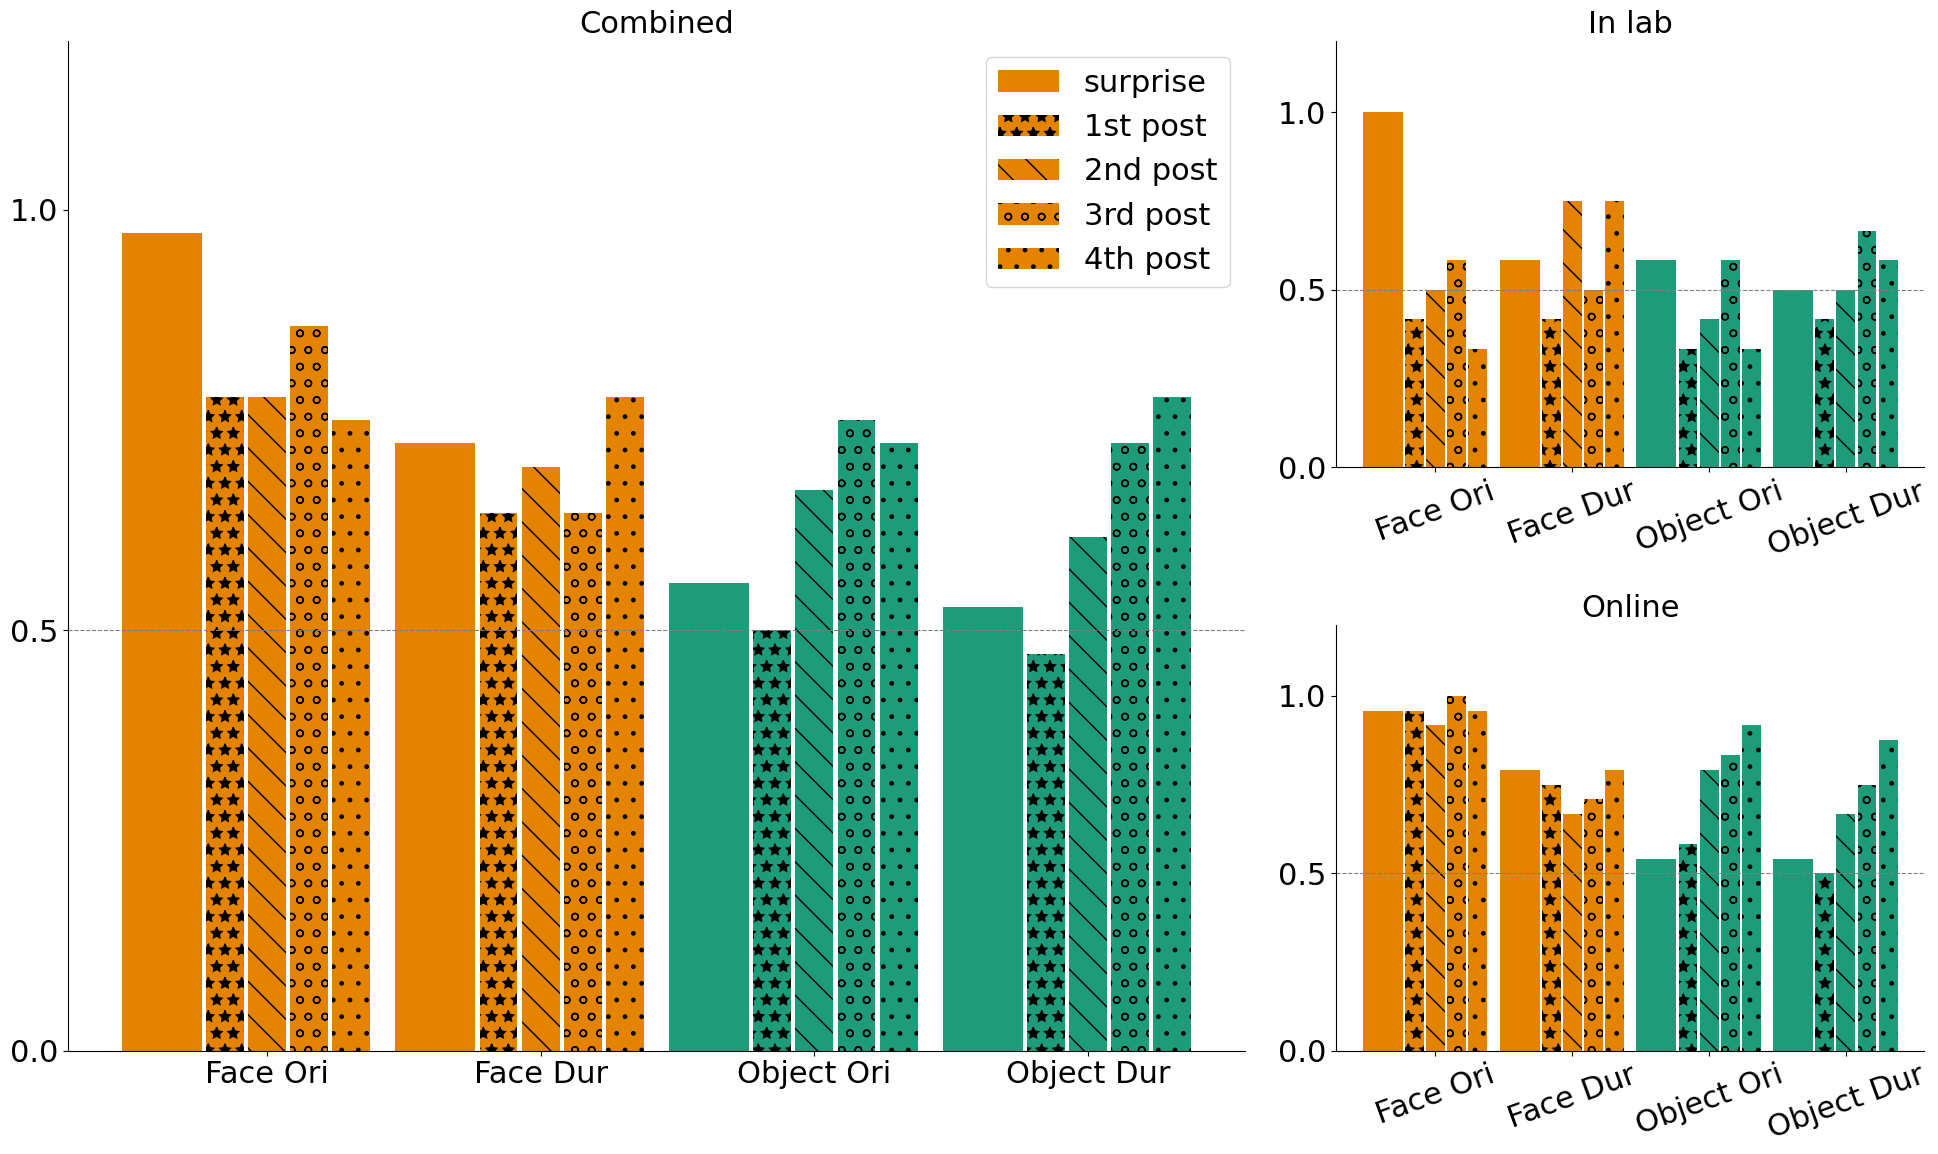

In [20]:
#| label: Figure6

# Plot the surprise vs. post surprise:
# Investigate the order effect:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Axes for combined and separate plots
ax_combined = fig.add_subplot(gs[:, 0])  # Combined plot takes the left 2x1 space
ax_lab = fig.add_subplot(gs[0, 1])       # Top-right for in-lab data
ax_online = fig.add_subplot(gs[1, 1])    # Bottom-right for online data

# Block types:
nth_post = ['surprise', 1, 2, 3, 4]
markers = ['', '*', '\\', 'o', '.']
legends = ['surprise', '1st post', '2nd post', '3rd post', '4th post']
# In lab study face orientation:
for i, (ax, online) in enumerate(zip([ax_lab, ax_online], online_flags)):
    ctr = 0
    for ii, grp in enumerate(['Face', 'Object']):
        for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
            ctr += 1
            for iiii, nth in enumerate(nth_post):
                if nth == 'surprise':
                    df = surprise_probe_data[(surprise_probe_data['online'] == online) &
                            (surprise_probe_data['event_type'] == prb) &
                            (surprise_probe_data['category'] == grp.lower())]
                    extra_width = 1
                else:
                    df = post_surprise_trials[(post_surprise_trials['online'] == online) &
                            (post_surprise_trials['event_type'] == prb) &
                            (post_surprise_trials['nth'] == nth) &
                            (post_surprise_trials['category'] == grp.lower())]
                    extra_width = 0
                # Extract probed first:
                if prb == 'probe_orientation':
                    data = df['orientation'].to_numpy() == df['response'].to_numpy()
                else:
                    data = df['duration_str'].to_numpy() == df['response'].to_numpy()
                # Plot the results:
                bar_height = np.sum(data) / data.shape[0]
                ax.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width + extra_width, hatch=markers[iiii])
                ctr += 1 + np.max([extra_width-0.5, 0])
    # Customize each subplot
    if online:
        ax.set_title(f'Online')
    else:
        ax.set_title(f'In lab')
    ax.set_xticks([3.5, 10, 16.5, 23])
    ax.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'], rotation=20)
    ax.spines[['right', 'top']].set_visible(False)
    # Set y-axis limits and ticks, with a dashed line at 0.5
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0, 0.5, 1])
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Combined
i = 2
ctr = 0
for ii, grp in enumerate(['Face', 'Object']):
    for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
        ctr += 1
        for iiii, nth in enumerate(nth_post):
            if nth == 'surprise':
                df = surprise_probe_data[(surprise_probe_data['event_type'] == prb) &
                        (surprise_probe_data['category'] == grp.lower())]
                extra_width = 1
            else:
                df = post_surprise_trials[(post_surprise_trials['event_type'] == prb) &
                        (post_surprise_trials['nth'] == nth) &
                        (post_surprise_trials['category'] == grp.lower())]
                extra_width = 0
            # Extract probed first:
            if prb == 'probe_orientation':
                data = df['orientation'].to_numpy() == df['response'].to_numpy()
            else:
                data = df['duration_str'].to_numpy() == df['response'].to_numpy()
            # Plot the results:
            bar_height = np.sum(data) / data.shape[0]
            ax_combined.bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width + extra_width, hatch=markers[iiii], label=legends[iiii] if ctr <= 6 else "")
            ctr += 1 + np.max([extra_width-0.5, 0])
ax_combined.set_xticks([3.5, 10, 16.5, 23])
ax_combined.set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'])
ax_combined.spines[['right', 'top']].set_visible(False)
# Set y-axis limits and ticks, with a dashed line at 0.5
ax_combined.set_ylim(0, 1.2)
ax_combined.set_yticks([0, 0.5, 1])
ax_combined.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax_combined.legend()
ax_combined.set_title("Combined")
plt.tight_layout()
plt.show()
plt.close()

Interestingly, it would seem that for faces, memory performances for both orientation and duration are already maxed out in the surprise trial, as we do not see any increasing trend in subsequent post-surprise trials. In the case of objects however, we do see a clear increasing trend, indicating that memory performance are improved by making the feature task relevant. This result pattern fits nicely with the interpretation that faces are processed in a more holistic fashion, such that most task irrelevant features are encoded in memory. 

Importantly, in the above plot, we are ignoring two important factors: probe order and congruency. In the above plot, the first and third control is derived from the congruent participant group, while the second and fourth control is derived from the incongruent participants group. To investigate both these effects, we need to further divide our data set. Due to the small sample size, we will limit this analysis to the combined data set.


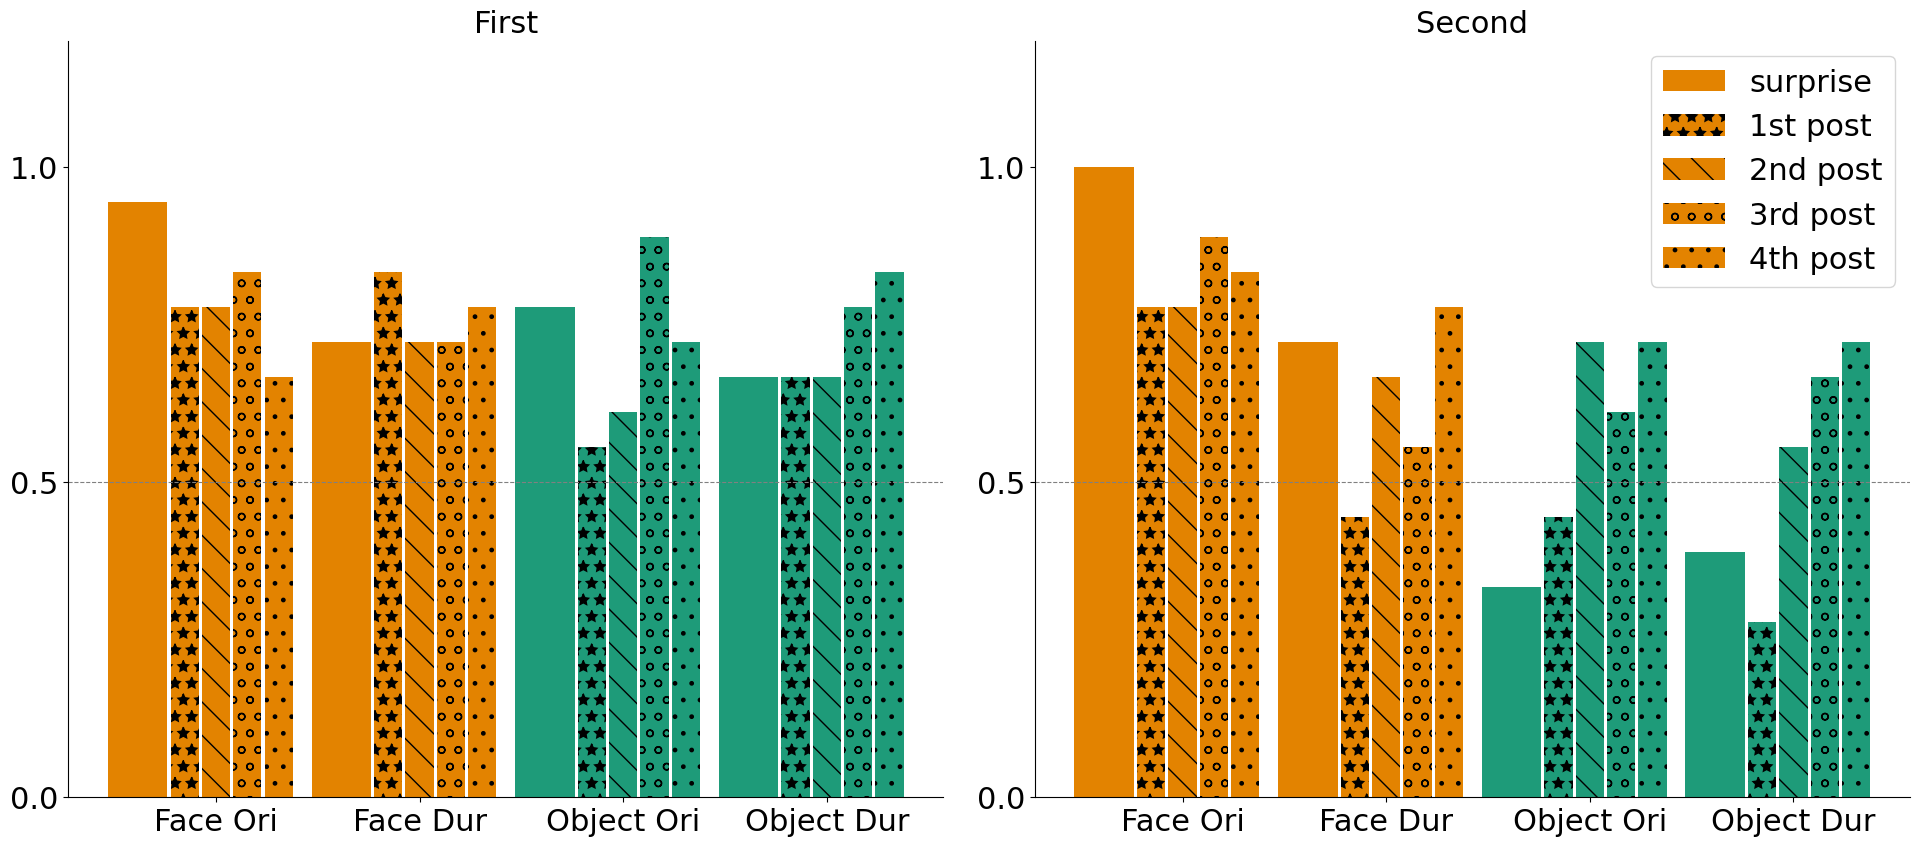

In [21]:
# pylustrator.start()
fig, ax = plt.subplots(2, figsize=(20, 12))

# Block types:
nth_post = ['surprise', 1, 2, 3, 4]
markers = ['', '*', '\\', 'o', '.']
legends = ['surprise', '1st post', '2nd post', '3rd post', '4th post']

for i, ord in enumerate(['First', 'Second']):
    ctr = 0
    for ii, grp in enumerate(['Face', 'Object']):
        for iii, prb in enumerate(['probe_orientation', 'probe_duration']):
            ctr += 1
            for iiii, nth in enumerate(nth_post):
                if nth == 'surprise':
                    df = surprise_probe_data[(surprise_probe_data['event_type'] == prb) &
                            (surprise_probe_data['category'] == grp.lower())]
                    extra_width = 1
                else:
                    df = post_surprise_trials[(post_surprise_trials['event_type'] == prb) &
                            (post_surprise_trials['nth'] == nth) &
                            (post_surprise_trials['category'] == grp.lower())]
                    extra_width = 0
                # Extract probed first:
                if prb == 'probe_orientation':
                    if ord == 'First':
                        df = df[df['probe_order'] == 'orientationFirst']
                    else:
                        df = df[df['probe_order'] == 'durationFirst']
                    data = df['orientation'].to_numpy() == df['response'].to_numpy()
                else:
                    if ord == 'First':
                        df = df[df['probe_order'] == 'durationFirst']
                    else:
                        df = df[df['probe_order'] == 'orientationFirst']
                    data = df['duration_str'].to_numpy() == df['response'].to_numpy()
                # Plot the results:
                bar_height = np.sum(data) / data.shape[0]
                ax[i].bar(ctr, bar_height, color=colors[grp.lower()], width=bar_width + extra_width, hatch=markers[iiii], label=legends[iiii] if ctr <= 6 else "")
                ctr += 1 + np.max([extra_width-0.5, 0])
    ax[i].set_xticks([3.5, 10, 16.5, 23])
    ax[i].set_xticklabels(['Face Ori', 'Face Dur', 'Object Ori', 'Object Dur'])
    ax[i].spines[['right', 'top']].set_visible(False)
    # Set y-axis limits and ticks, with a dashed line at 0.5
    ax[i].set_ylim(0, 1.2)
    ax[i].set_yticks([0, 0.5, 1])
    ax[i].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax[i].legend()
    ax[i].set_title(ord)
plt.tight_layout()
#% start: automatic generated code from pylustrator
plt.figure(1).ax_dict = {ax.get_label(): ax for ax in plt.figure(1).axes}
import matplotlib as mpl
getattr(plt.figure(1), '_pylustrator_init', lambda: ...)()
plt.figure(1).set_size_inches(50.710000/2.54, 24.000000/2.54, forward=True)
plt.figure(1).axes[0].set(position=[0.04555, 0.2793, 0.4441, 0.6685])
plt.figure(1).axes[0].set_position([0.044969, 0.136801, 0.438413, 0.800644])
plt.figure(1).axes[0].get_legend().set(visible=False)
plt.figure(1).axes[1].set(position=[0.5359, 0.2793, 0.4441, 0.6685])
plt.figure(1).axes[1].set_position([0.529122, 0.136801, 0.438413, 0.800644])
#% end: automatic generated code from pylustrator
plt.show()

As we have observed before, for the surprise trial, the orer of the probe does make a strong difference for bpth features in the case of the objects but not for the faces. In the case of the post-surprise trial, while the memory performances are not as good in the case of the 